# Phase 2: AdaFoB Hypothesis Validation Pilot

This notebook validates two core hypotheses of the AdaFoB project using **frozen SAM ViT-H** inference (no training):

- **Claim A**: A shape-adaptive Np beats every fixed Np on irregular structures.
- **Claim B**: Skeleton-derived background prompt placement beats the ring/dilation-band prior on HD95 for irregular structures.

**Hardware**: Kaggle GPU T4 x2 (uses only `cuda:0`).

---

## Dataset Setup Instructions

### A) BraTS2020 (Required - Irregular Structure Benchmark)
1. In the Kaggle Notebook editor, click **Add Input** (right sidebar).
2. Search for **"BraTS2020"** and add the dataset (e.g., `awsaf49/brats20-dataset-training-validation`).
3. It will mount read-only at `/kaggle/input/<dataset-slug>/`.
4. **Label convention**: Tumor core = union of labels {1, 4} (necrotic + enhancing tumor). Label 2 = edema (excluded). Label 3 is absent in BraTS2020.

### B) Abd-CT / BTCV (Required - Compact Control)
**Option 1 (Recommended)**: Search Kaggle Datasets for **"BTCV abdomen CT"** or **"Synapse multi-organ"** and add as input. Document the exact slug in the path-resolution cell below.

**Option 2 (Synapse download)**: If no Kaggle mirror is available:
1. Register at https://www.synapse.org and join syn3193805.
2. Add your Synapse Personal Access Token as Kaggle Secret `SYNAPSE_TOKEN`.
3. Uncomment the Synapse download cell below.

### C) DRIVE (Optional - Cross-Domain Appendix)
1. **Add Input** -> search **"DRIVE retinal vessel segmentation"** -> add.
2. If skipped, leave `DRIVE_ROOT = None` -- the scripts handle this gracefully.

### D) GitHub Token (if repo is private)
If the repo is private, add a GitHub Personal Access Token as Kaggle Secret `GITHUB_TOKEN`. The clone command below will use it automatically.

---
## 1. Environment Setup

In [13]:
import os

# Clone the repo
repo_dir = '/kaggle/working/AdaFoB'

if not os.path.isdir(repo_dir):
    # If repo is private, use GITHUB_TOKEN secret:
    try:
        from kaggle_secrets import UserSecretsClient
        secrets = UserSecretsClient()
        token = secrets.get_secret('GITHUB_TOKEN')
        !git clone https://{token}@github.com/PhoenixEvo/AdaFoB.git {repo_dir}
    except Exception:
        # Public repo fallback
        !git clone https://github.com/PhoenixEvo/AdaFoB.git {repo_dir}
else:
    # Pull latest
    !cd {repo_dir} && git pull

%cd {repo_dir}
print(f'Working directory: {os.getcwd()}')

Already up to date.
/kaggle/working/AdaFoB
Working directory: /kaggle/working/AdaFoB


In [14]:
# Install additional packages not preinstalled on Kaggle
!pip install -q segment-anything medpy skan pyyaml

In [15]:
# Download SAM ViT-H checkpoint
!mkdir -p /kaggle/working/checkpoints
!wget -nc https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth \
    -P /kaggle/working/checkpoints/
!ls -lh /kaggle/working/checkpoints/

File ‘/kaggle/working/checkpoints/sam_vit_h_4b8939.pth’ already there; not retrieving.

total 2.4G
-rw-r--r-- 1 root root 2.4G Apr  4  2023 sam_vit_h_4b8939.pth


---
## 2. Path Resolution

Set dataset paths to match your Kaggle input mounts. Edit the slugs below to match what you added.

In [16]:
import os
import glob

# Auto-detect dataset paths dynamically in /kaggle/input
BRATS_ROOT = None
ABDCT_ROOT = None
DRIVE_ROOT = None

# Search for BraTS
brats_candidates = glob.glob('/kaggle/input/**/*BraTS20_Training_*', recursive=True)
if brats_candidates:
    BRATS_ROOT = os.path.dirname(brats_candidates[0])
    print(f'BraTS root auto-detected: {BRATS_ROOT}')
else:
    print(f'[WARN] BraTS not found in /kaggle/input')

# Search for Abd-CT
abdct_candidates = glob.glob('/kaggle/input/**/*averaged-training-images*', recursive=True)
if abdct_candidates:
    ABDCT_ROOT = os.path.dirname(abdct_candidates[0])
    print(f'AbdCT root auto-detected: {ABDCT_ROOT}')
else:
    print(f'[WARN] Abd-CT not found in /kaggle/input')

# Search for DRIVE
drive_candidates = glob.glob('/kaggle/input/**/*DRIVE*', recursive=True)
if drive_candidates:
    DRIVE_ROOT = drive_candidates[0]
    print(f'DRIVE root auto-detected: {DRIVE_ROOT}')
else:
    print(f'[SKIP] DRIVE not found in /kaggle/input')

# ---- SAM checkpoint ----
SAM_CHECKPOINT = '/kaggle/working/checkpoints/sam_vit_h_4b8939.pth'

# Set environment variables
os.environ['BRATS_ROOT'] = BRATS_ROOT or ''
os.environ['ABDCT_ROOT'] = ABDCT_ROOT or ''
os.environ['DRIVE_ROOT'] = DRIVE_ROOT or ''
os.environ['SAM_CHECKPOINT'] = SAM_CHECKPOINT

print('Environment variables set.')

BraTS root auto-detected: /kaggle/input/datasets/awsaf49/brats20-dataset-training-validation/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
AbdCT root auto-detected: /kaggle/input/datasets/nhatphatnguyen/abd-ct/abd-ct
DRIVE root auto-detected: /kaggle/input/datasets/nhatphatnguyen/drive-dataset/DRIVE
Environment variables set.


In [17]:
# Optional: Synapse download (uncomment if BTCV mirror is not available)
# !pip install -q synapseclient
# import synapseclient
# from kaggle_secrets import UserSecretsClient
# secrets = UserSecretsClient()
# syn = synapseclient.Synapse()
# syn.login(authToken=secrets.get_secret('SYNAPSE_TOKEN'))
# 
# # Download specific SABS files - adjust entity IDs as needed
# import os
# os.makedirs('/kaggle/working/data/abdct_pilot', exist_ok=True)
# # syn.get('synXXXXXXX', downloadLocation='/kaggle/working/data/abdct_pilot')
# print('Synapse download complete.')

---
## 3. Sanity Check: Shape Features

Quick test on synthetic masks to verify the shape feature computation works.

In [18]:
import time
t0 = time.time()

# Run the built-in sanity check
!python experiments/pilot/shape_features.py

elapsed = time.time() - t0
print(f'\nShape features sanity check elapsed: {elapsed:.1f}s')

Running sanity checks...

--- Circle Mask ---
area: 7845
perimeter: 329.7056245803833
compactness: 0.9068805756952045
skeleton_length: 1
num_branches: 0
Heuristic Np: 14

--- Star Mask ---
area: 5053
perimeter: 684.1391710042953
compactness: 0.13566575876878179
skeleton_length: 359
num_branches: 5
Heuristic Np: 35

Shape features sanity check elapsed: 4.3s


---
## 4. Collect Shape Features

Runs `collect_shape_features.py` to extract features from all pilot cases and save to CSV.

In [19]:
import time
import torch

t0 = time.time()
if torch.cuda.is_available():
    start_event = torch.cuda.Event(enable_timing=True)
    end_event = torch.cuda.Event(enable_timing=True)
    start_event.record()

!python experiments/pilot/collect_shape_features.py

if torch.cuda.is_available():
    end_event.record()
    torch.cuda.synchronize()
    gpu_ms = start_event.elapsed_time(end_event)
    print(f'GPU time: {gpu_ms/1000:.1f}s')

elapsed = time.time() - t0
print(f'Wall time: {elapsed:.1f}s')

[WARN] No label files found in /kaggle/input/datasets/nhatphatnguyen/abd-ct/abd-ct. Skipping Abd-CT.
  Found 0 Abd-CT cases.
  Found 10 BraTS cases.
  Found 5 DRIVE cases.

Total cases collected: 15
  BraTS20_Training_001_s088_tumor          | area=  2312 | compact=0.409 | skel_len= 157 | branches=  9 | Np=17
  BraTS20_Training_002_s078_tumor          | area=  1581 | compact=0.734 | skel_len=  60 | branches=  3 | Np=12
  BraTS20_Training_003_s168_tumor          | area=   501 | compact=0.664 | skel_len=  39 | branches=  5 | Np=12
  BraTS20_Training_004_s163_tumor          | area=  2254 | compact=0.613 | skel_len=  97 | branches=  5 | Np=14
  BraTS20_Training_005_s160_tumor          | area=  1191 | compact=0.600 | skel_len=  84 | branches=  6 | Np=14
  BraTS20_Training_006_s139_tumor          | area=  3222 | compact=0.564 | skel_len= 242 | branches= 14 | Np=15
  BraTS20_Training_007_s160_tumor          | area=   937 | compact=0.227 | skel_len= 136 | branches= 13 | Np=18
  BraTS20_Trainin

In [20]:
# Inspect the shape features CSV
import pandas as pd
df = pd.read_csv('results/pilot/pilot_shape_features.csv')
print(f'Total cases: {len(df)}')
print(f'\nDataset distribution:')
print(df['dataset'].value_counts())
print(f'\nNp_heuristic stats:')
print(df.groupby('dataset')['Np_heuristic'].describe())
df

Total cases: 15

Dataset distribution:
dataset
BraTS    10
DRIVE     5
Name: count, dtype: int64

Np_heuristic stats:
         count  mean       std   min   25%   50%   75%   max
dataset                                                     
BraTS     10.0  14.5  2.368778  11.0  12.5  14.5  16.5  18.0
DRIVE      5.0  24.0  0.000000  24.0  24.0  24.0  24.0  24.0


,case_id,dataset,organ,area,perimeter,compactness,skeleton_length,num_branches,Np_heuristic
0,BraTS20_Training_001_s088_tumor,BraTS,tumor_core,2312,266.51,0.4090,157,9,17
1,BraTS20_Training_002_s078_tumor,BraTS,tumor_core,1581,164.57,0.7336,60,3,12
2,BraTS20_Training_003_s168_tumor,BraTS,tumor_core,501,97.36,0.6642,39,5,12
3,BraTS20_Training_004_s163_tumor,BraTS,tumor_core,2254,214.95,0.6130,97,5,14
4,BraTS20_Training_005_s160_tumor,BraTS,tumor_core,1191,157.98,0.5997,84,6,14
5,BraTS20_Training_006_s139_tumor,BraTS,tumor_core,3222,267.82,0.5645,242,14,15
6,BraTS20_Training_007_s160_tumor,BraTS,tumor_core,937,227.92,0.2267,136,13,18
7,BraTS20_Training_008_s083_tumor,BraTS,tumor_core,238,67.21,0.6620,25,5,11
8,BraTS20_Training_009_s085_tumor,BraTS,tumor_core,4668,350.45,0.4776,334,15,17
9,BraTS20_Training_010_s084_tumor,BraTS,tumor_core,823,146.57,0.4814,85,7,15


---
## 5. Run Pilot Comparison

Runs `run_pilot.py` -- the main experiment. This loads SAM ViT-H and evaluates all 6 arms.

In [21]:
import time

t0 = time.time()

!python experiments/pilot/run_pilot.py

elapsed = time.time() - t0
print(f'\nTotal wall time for pilot: {elapsed:.1f}s ({elapsed/3600:.3f} hours)')

Loading SAM ViT-H from /kaggle/working/checkpoints/sam_vit_h_4b8939.pth ...
SAM loaded on cuda:0.
Loaded 15 pilot cases.
Arms: ['A1_ring_np5', 'A2_ring_np10', 'A3_ring_np20', 'A4_ring_heuristic', 'A5_skel_heuristic', 'A6_skel_np10']

[1/15] BraTS20_Training_001_s088_tumor (dataset=BraTS, Np_h=17)
  A1_ring_np5               Np=  5 Dice=0.6851 HD95=14.14
  A2_ring_np10              Np= 10 Dice=0.7934 HD95=12.07
  A3_ring_np20              Np= 20 Dice=0.8113 HD95=16.51
  A4_ring_heuristic         Np= 17 Dice=0.7608 HD95=22.95
  A5_skel_heuristic         Np= 17 Dice=0.7711 HD95=17.36
  A6_skel_np10              Np= 10 Dice=0.7280 HD95=12.81

[2/15] BraTS20_Training_002_s078_tumor (dataset=BraTS, Np_h=12)
  A1_ring_np5               Np=  5 Dice=0.7550 HD95=14.00
  A2_ring_np10              Np= 10 Dice=0.8013 HD95=10.00
  A3_ring_np20              Np= 20 Dice=0.7338 HD95=10.08
  A4_ring_heuristic         Np= 12 Dice=0.8072 HD95=9.04
  A5_skel_heuristic         Np= 12 Dice=0.7842 HD95=8.02
 

In [22]:
# Show GPU timing
with open('logs/pilot_gpu_time.txt', 'r') as f:
    print(f.read())

GPU time (ms): 242383.3
GPU time (hours): 0.0673
Wall time (s): 242.4
Wall time (hours): 0.0673
Cases: 15
Arms: 6
Total inferences: 90



---
## 6. Results

In [23]:
import pandas as pd

# Per-case metrics
metrics = pd.read_csv('results/pilot/pilot_metrics.csv')
print(f'Total rows: {len(metrics)}')
print(f'Cases: {metrics["case_id"].nunique()}')
print(f'Arms: {metrics["arm"].nunique()}')
metrics

Total rows: 90
Cases: 15
Arms: 6


,case_id,dataset,arm,Np_used,dice,hd95
0,BraTS20_Training_001_s088_tumor,BraTS,A1_ring_np5,5,0.6851,14.14
1,BraTS20_Training_001_s088_tumor,BraTS,A2_ring_np10,10,0.7934,12.07
2,BraTS20_Training_001_s088_tumor,BraTS,A3_ring_np20,20,0.8113,16.51
3,BraTS20_Training_001_s088_tumor,BraTS,A4_ring_heuristic,17,0.7608,22.95
4,BraTS20_Training_001_s088_tumor,BraTS,A5_skel_heuristic,17,0.7711,17.36
...,...,...,...,...,...,...
85,drive_25_manual1,DRIVE,A2_ring_np10,10,0.2057,29.68
86,drive_25_manual1,DRIVE,A3_ring_np20,20,0.1974,71.75
87,drive_25_manual1,DRIVE,A4_ring_heuristic,24,0.1987,71.70
88,drive_25_manual1,DRIVE,A5_skel_heuristic,24,0.1927,67.98


In [24]:
# Summary stats
summary = pd.read_csv('results/pilot/pilot_summary_stats.csv')
summary

,arm,dataset,n_cases,dice_mean,dice_std,hd95_mean,hd95_std
0,A1_ring_np5,BraTS,10.0,0.5811,0.2772,28.51,30.69
1,A1_ring_np5,DRIVE,5.0,0.1985,0.0421,58.17,25.16
2,A2_ring_np10,BraTS,10.0,0.5991,0.2883,37.12,40.25
3,A2_ring_np10,DRIVE,5.0,0.1890,0.0395,42.24,27.54
4,A3_ring_np20,BraTS,10.0,0.5975,0.2933,34.38,38.33
5,A3_ring_np20,DRIVE,5.0,0.1771,0.0366,82.33,9.12
6,A4_ring_heuristic,BraTS,10.0,0.5934,0.2944,34.93,36.78
7,A4_ring_heuristic,DRIVE,5.0,0.1775,0.0358,81.47,9.00
8,A5_skel_heuristic,BraTS,10.0,0.5913,0.2992,34.85,36.65
9,A5_skel_heuristic,DRIVE,5.0,0.1807,0.0330,69.94,21.81


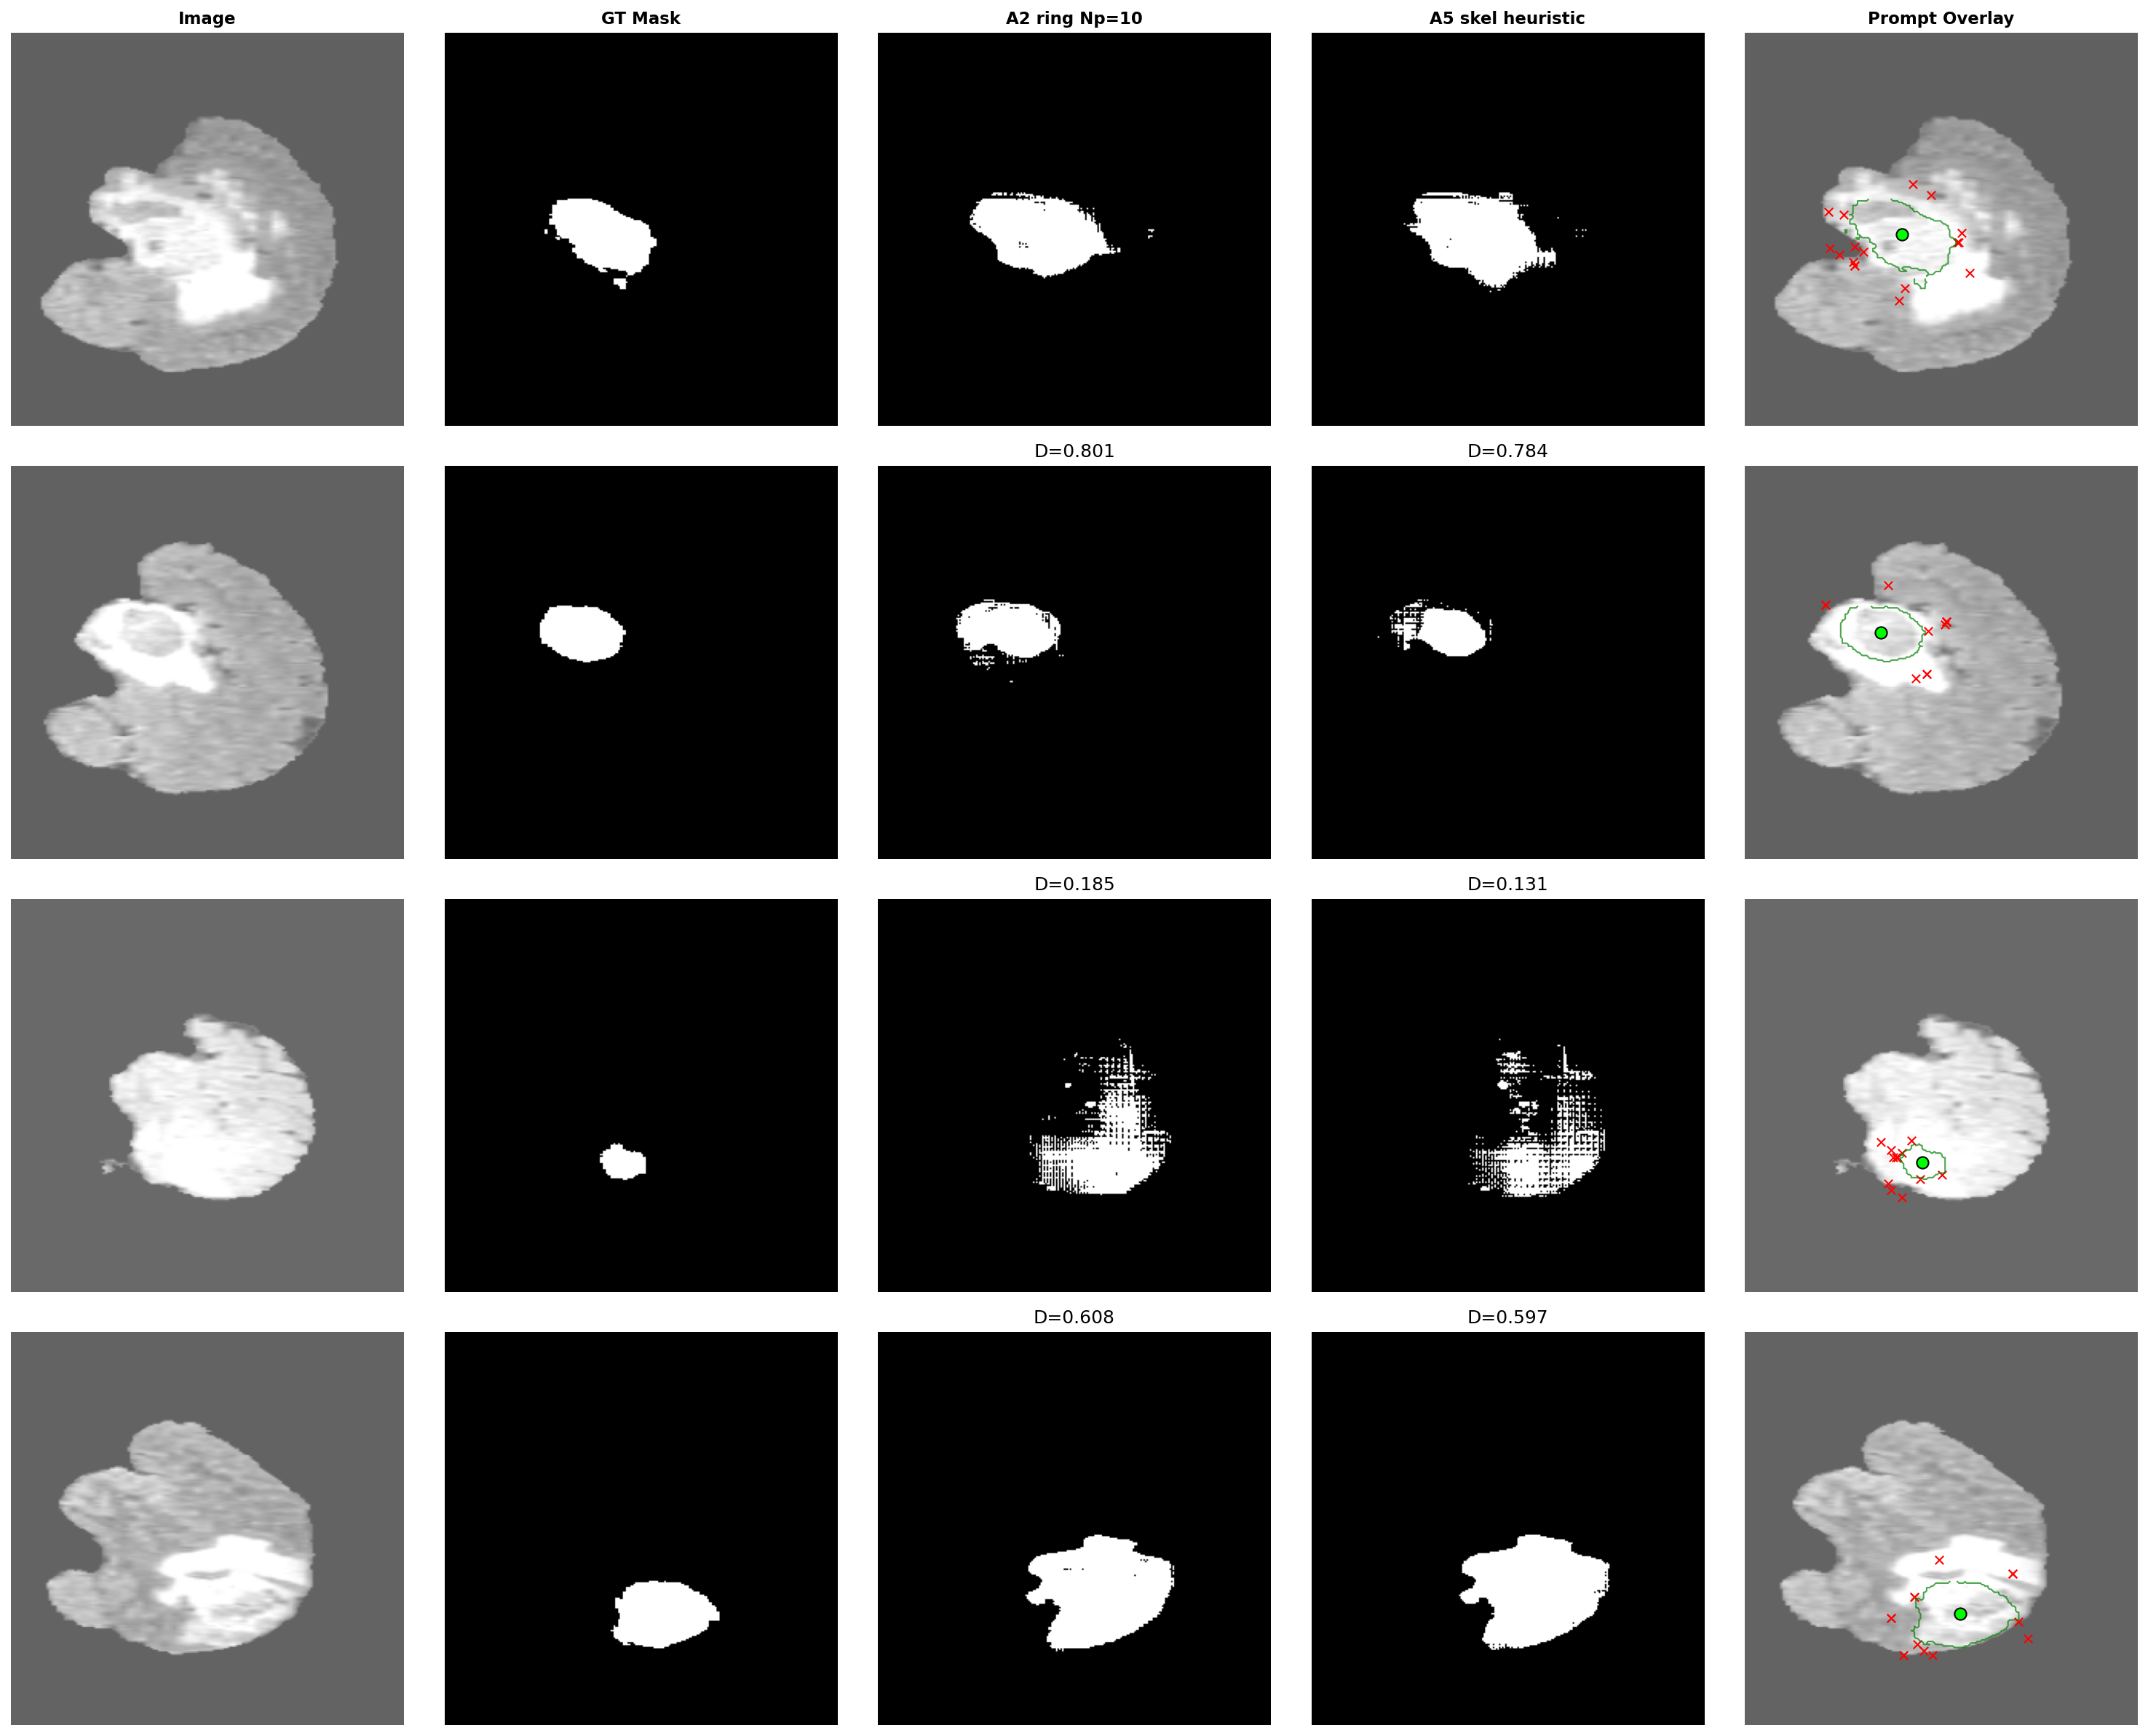

In [25]:
# Show comparison figure
from IPython.display import Image, display
import os

comp_path = 'figures/pilot/comparison_examples.png'
if os.path.isfile(comp_path):
    display(Image(filename=comp_path))
else:
    print(f'Comparison figure not found: {comp_path}')

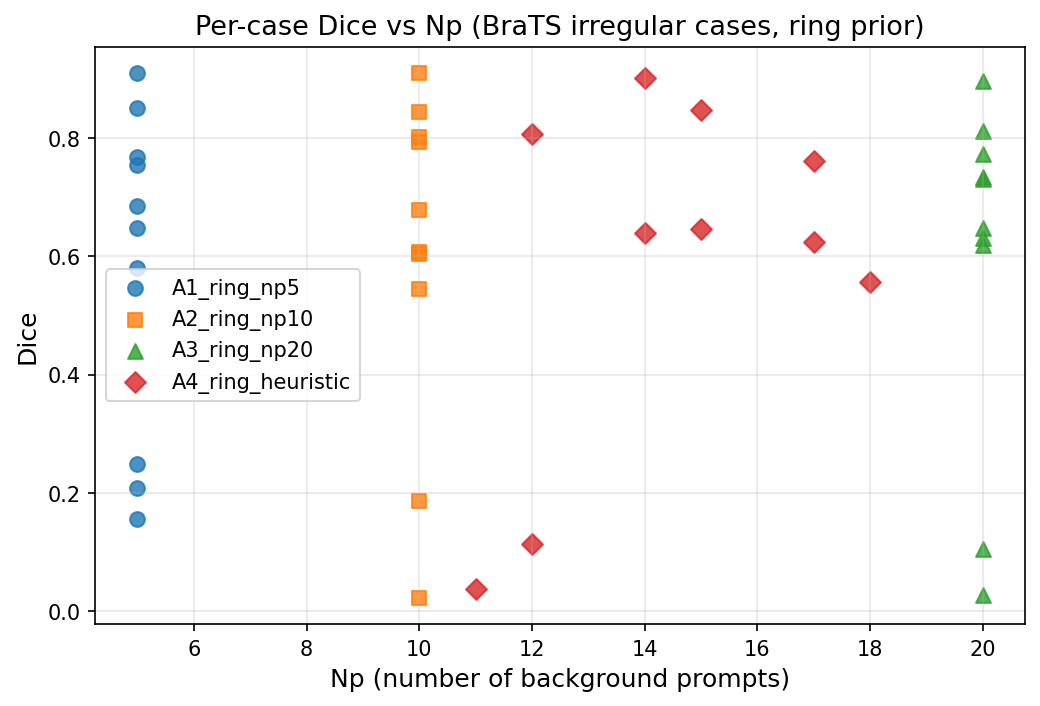

In [26]:
# Show Np vs Dice figure
np_dice_path = 'figures/pilot/np_vs_dice.png'
if os.path.isfile(np_dice_path):
    display(Image(filename=np_dice_path))
else:
    print(f'Np vs Dice figure not found: {np_dice_path}')

debug_BraTS20_Training_001_s088_tumor_A1_ring_np5.png


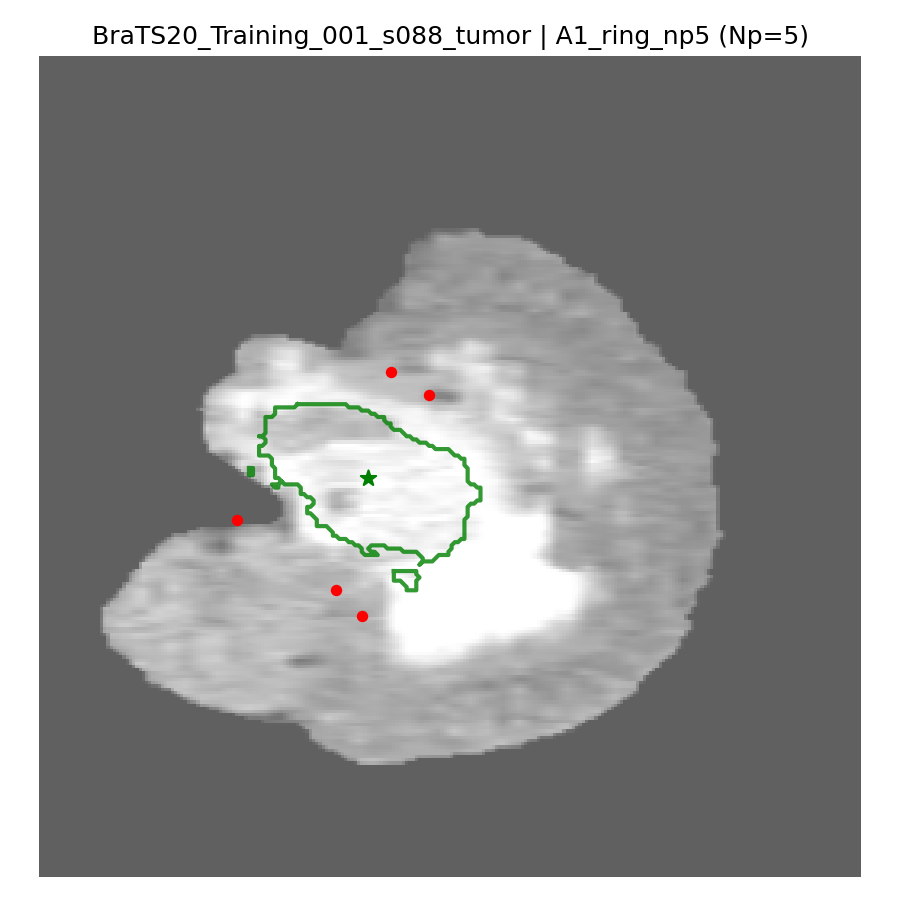

debug_BraTS20_Training_001_s088_tumor_A2_ring_np10.png


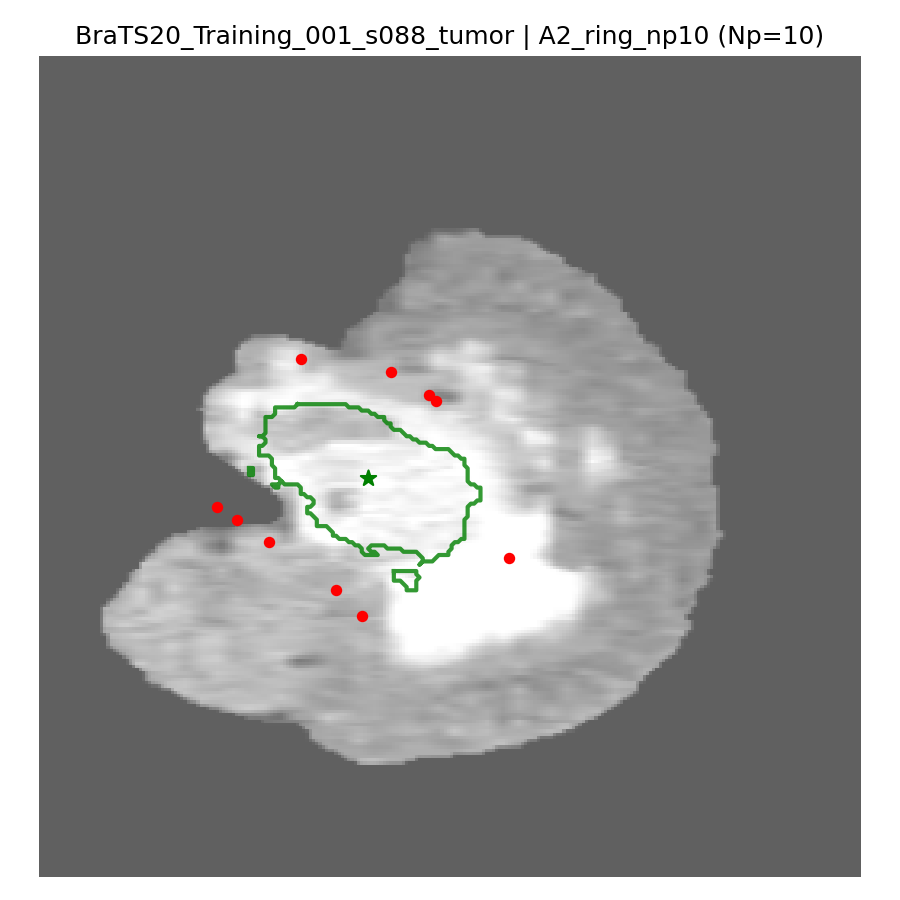

debug_BraTS20_Training_001_s088_tumor_A3_ring_np20.png


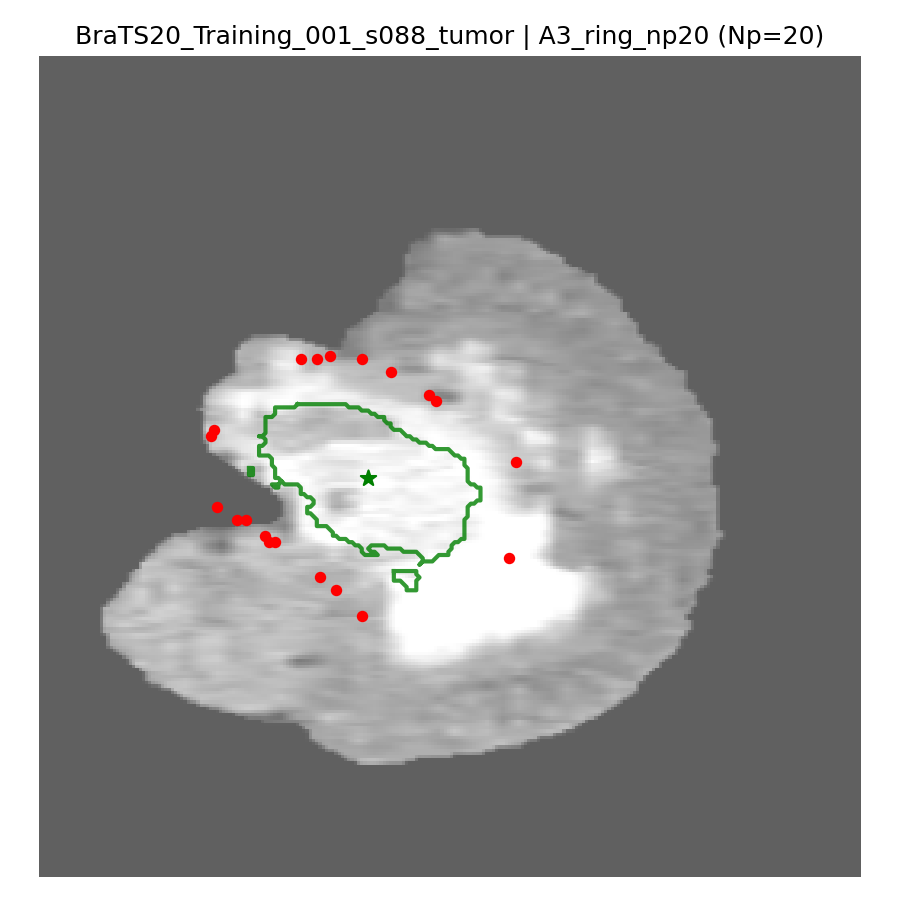

debug_BraTS20_Training_001_s088_tumor_A4_ring_heuristic.png


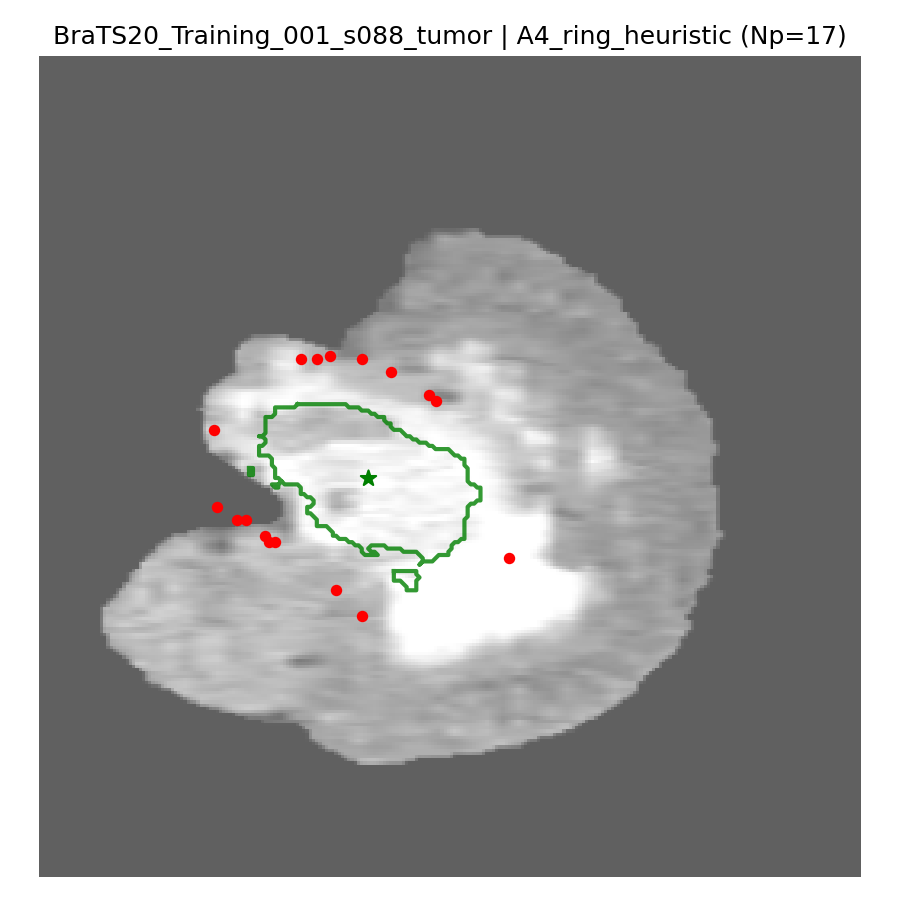

debug_BraTS20_Training_001_s088_tumor_A5_skel_heuristic.png


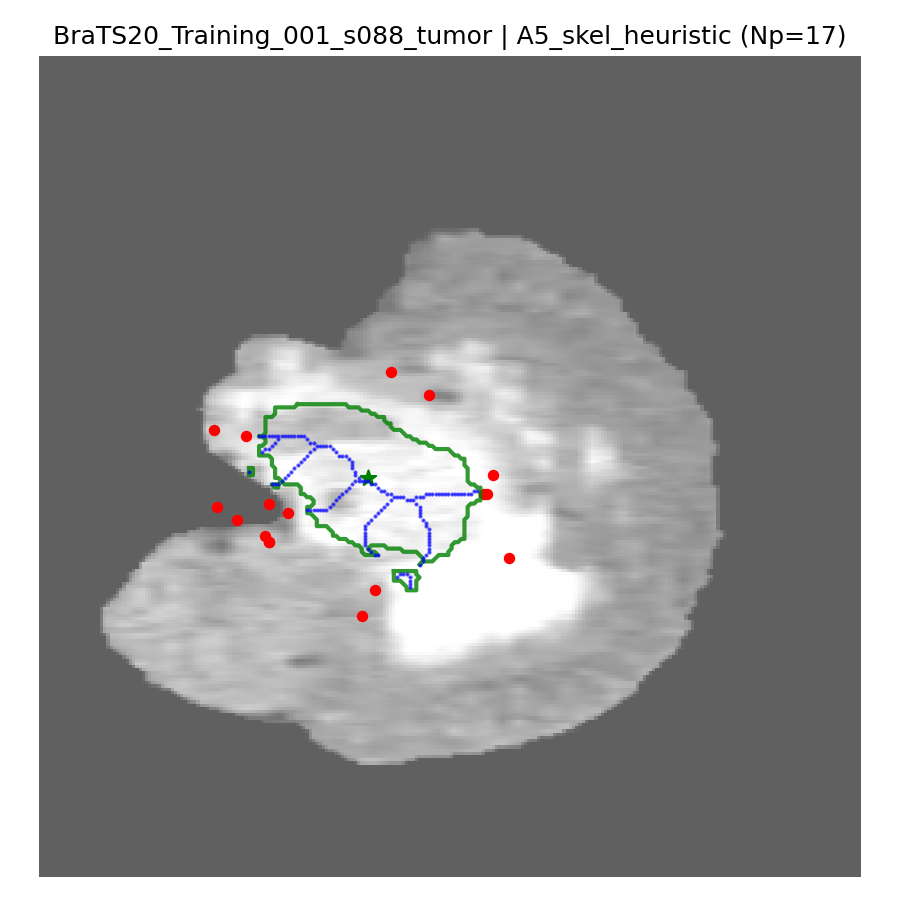

debug_BraTS20_Training_001_s088_tumor_A6_skel_np10.png


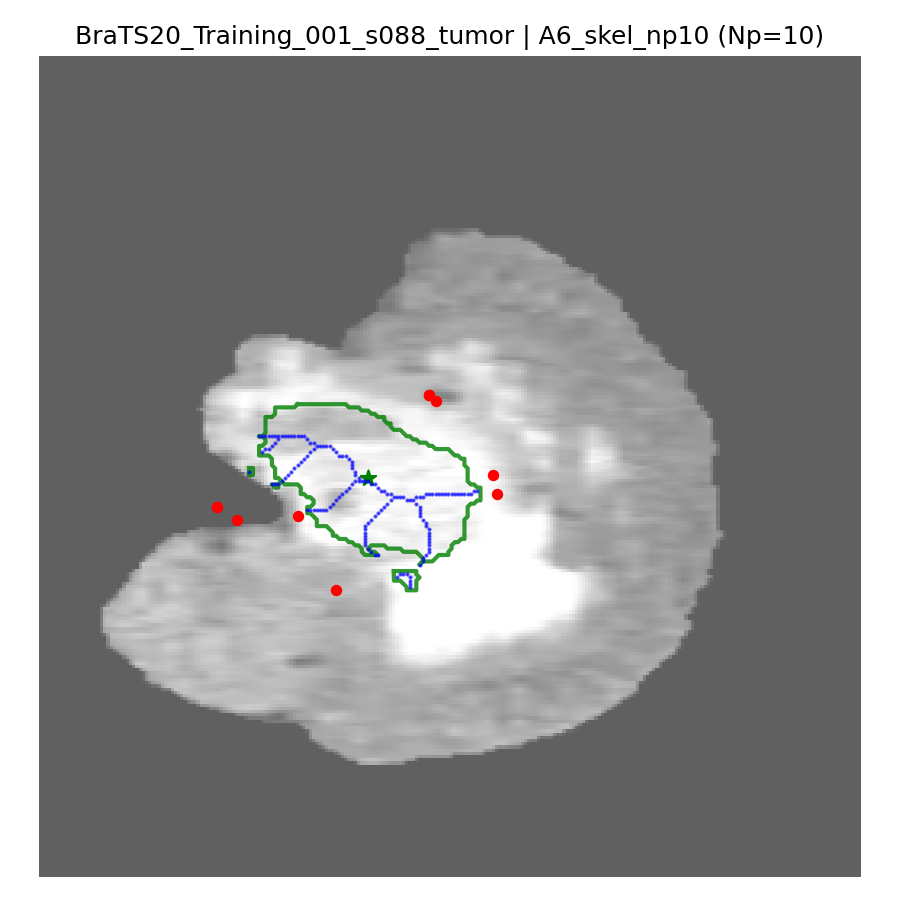

In [27]:
# Show some debug overlays
import glob
from IPython.display import Image, display

debug_files = sorted(glob.glob('figures/pilot/debug_*.png'))[:6]
for f in debug_files:
    print(os.path.basename(f))
    display(Image(filename=f, width=400))

---
## 7. Package Outputs

In [28]:
import shutil

output_zip = '/kaggle/working/phase2_outputs.zip'

# Zip results, figures, logs, notes
!cd /kaggle/working/AdaFoB && zip -r {output_zip} results/ figures/ logs/ notes/ \
    -x '*/masks/*'

print(f'\nOutput zip: {output_zip}')
print('Download from the Kaggle "Output" tab on the right sidebar.')
!ls -lh {output_zip}

  adding: results/ (stored 0%)
  adding: results/pilot/ (stored 0%)
  adding: results/pilot/pilot_metrics.csv (deflated 82%)
  adding: results/pilot/pilot_shape_features.csv (deflated 61%)
  adding: results/pilot/pilot_summary_stats.csv (deflated 53%)
  adding: results/README.md (deflated 12%)
  adding: figures/ (stored 0%)
  adding: figures/pilot/ (stored 0%)
  adding: figures/pilot/debug_BraTS20_Training_001_s088_tumor_A2_ring_np10.png (deflated 9%)
  adding: figures/pilot/debug_BraTS20_Training_004_s163_tumor_A5_skel_heuristic.png (deflated 10%)
  adding: figures/pilot/debug_BraTS20_Training_003_s168_tumor_A4_ring_heuristic.png (deflated 15%)
  adding: figures/pilot/debug_BraTS20_Training_004_s163_tumor_A3_ring_np20.png (deflated 10%)
  adding: figures/pilot/debug_BraTS20_Training_005_s160_tumor_A2_ring_np10.png (deflated 10%)
  adding: figures/pilot/debug_BraTS20_Training_004_s163_tumor_A1_ring_np5.png (deflated 11%)
  adding: figures/pilot/debug_BraTS20_Training_005_s160_tumor_A1_

In [29]:
# Optional: Commit and push results back to GitHub
# Uncomment below if you have GITHUB_TOKEN set and want to push from Kaggle.

# import os
# from kaggle_secrets import UserSecretsClient
# secrets = UserSecretsClient()
# token = secrets.get_secret('GITHUB_TOKEN')
# 
# !cd /kaggle/working/AdaFoB && \
#   git config user.email 'pilot@adafob.local' && \
#   git config user.name 'AdaFoB Pilot Bot' && \
#   git add results/ figures/ logs/ notes/ && \
#   git commit -m 'Phase 2 pilot results from Kaggle' && \
#   git push https://{token}@github.com/PhoenixEvo/AdaFoB.git main
# print('Pushed results to GitHub.')